# Vroom Forecast — Exploration Notebook

**Goal:** Understand which vehicle attributes drive the total number of reservations.

Datasets:
- `vehicles.csv` — 1000 vehicles with their attributes
- `reservations.csv` — ~6400 completed reservations

Plan:
1. Load and inspect both datasets
2. Aggregate reservations per vehicle and merge with vehicle features
3. Exploratory analysis and visualizations
4. Train a model to identify the most important features
5. Log experiments to MLflow
6. Present key insights

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Resolve paths relative to the repo root (works regardless of kernel cwd)
REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
DATA_DIR = REPO_ROOT / "data"

## 2. MLflow Setup

In [2]:
mlflow.set_tracking_uri("http://localhost:5001")
mlflow.set_experiment("vroom-forecast-exploration")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {mlflow.get_experiment_by_name('vroom-forecast-exploration')}")

2026/04/08 15:09:08 INFO mlflow.tracking.fluent: Experiment with name 'vroom-forecast-exploration' does not exist. Creating a new experiment.


MLflow tracking URI: http://localhost:5001
Experiment: <Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1775653748382, experiment_id='2', last_update_time=1775653748382, lifecycle_stage='active', name='vroom-forecast-exploration', tags={}, workspace='default'>


## 3. Load and Inspect Data

### 3.1 Vehicles

In [3]:
vehicles = pd.read_csv(DATA_DIR / "vehicles.csv")
print(f"Shape: {vehicles.shape}")
vehicles.head()

Shape: (1000, 7)


,vehicle_id,technology,actual_price,recommended_price,num_images,street_parked,description
0,1,1,67.85,59,5,0,7
1,2,0,100.70,53,5,0,224
2,3,0,74.00,74,4,1,21
3,4,0,135.00,75,1,0,184
4,5,0,59.36,53,2,1,31


In [4]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vehicle_id         1000 non-null   int64  
 1   technology         1000 non-null   int64  
 2   actual_price       1000 non-null   float64
 3   recommended_price  1000 non-null   int64  
 4   num_images         1000 non-null   int64  
 5   street_parked      1000 non-null   int64  
 6   description        1000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 54.8 KB


In [5]:
vehicles.describe()

,vehicle_id,technology,actual_price,recommended_price,num_images,street_parked,description
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,0.170000,87.940730,62.206000,3.008000,0.511000,90.792000
std,288.819436,0.375821,29.724589,16.082544,1.348983,0.500129,76.948644
min,1.000000,0.000000,32.760000,35.000000,1.000000,0.000000,1.000000
25%,250.750000,0.000000,64.942500,49.000000,2.000000,0.000000,25.000000
50%,500.500000,0.000000,83.930000,62.000000,3.000000,1.000000,57.500000
75%,750.250000,0.000000,107.010000,76.000000,4.000000,1.000000,158.000000
max,1000.000000,1.000000,174.440000,90.000000,5.000000,1.000000,250.000000


### 3.2 Reservations

In [6]:
reservations = pd.read_csv(DATA_DIR / "reservations.csv", parse_dates=["created_at"])
print(f"Shape: {reservations.shape}")
reservations.head()

Shape: (6376, 2)


,vehicle_id,created_at
0,208,2023-07-27 14:58:26
1,601,2023-04-18 09:36:57
2,993,2023-12-25 01:22:09
3,423,2023-07-26 04:54:19
4,685,2023-11-26 15:21:35


In [7]:
reservations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6376 entries, 0 to 6375
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   vehicle_id  6376 non-null   int64         
 1   created_at  6376 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 99.8 KB


In [8]:
reservations["created_at"].describe()

count                             6376
mean     2023-06-30 11:32:38.177227008
min                2023-01-01 03:49:58
25%      2023-03-29 19:04:49.750000128
50%         2023-06-29 14:33:33.500000
75%      2023-09-29 02:05:15.750000128
max                2023-12-30 21:35:31
Name: created_at, dtype: object

## 4. Data Preparation

Aggregate reservations per vehicle and merge with vehicle attributes.

In [9]:
# Count reservations per vehicle
res_counts = reservations.groupby("vehicle_id").size().reset_index(name="num_reservations")
print(f"Vehicles with at least 1 reservation: {len(res_counts)}")
res_counts.describe()

Vehicles with at least 1 reservation: 911


,vehicle_id,num_reservations
count,911.000000,911.000000
mean,494.600439,6.998902
std,288.242005,4.645333
min,1.000000,1.000000
25%,245.500000,3.000000
50%,493.000000,6.000000
75%,739.500000,10.000000
max,1000.000000,25.000000


In [10]:
# Merge with vehicle features (left join to keep all vehicles)
df = vehicles.merge(res_counts, on="vehicle_id", how="left")
df["num_reservations"] = df["num_reservations"].fillna(0).astype(int)
print(f"Final dataset shape: {df.shape}")
print(f"Vehicles with 0 reservations: {(df['num_reservations'] == 0).sum()}")
df.head()

Final dataset shape: (1000, 8)
Vehicles with 0 reservations: 89


,vehicle_id,technology,actual_price,recommended_price,num_images,street_parked,description,num_reservations
0,1,1,67.85,59,5,0,7,1
1,2,0,100.70,53,5,0,224,7
2,3,0,74.00,74,4,1,21,17
3,4,0,135.00,75,1,0,184,2
4,5,0,59.36,53,2,1,31,2


## 5. Exploratory Data Analysis

We have 1,000 vehicles with 6 raw attributes and a target variable
(`num_reservations`). Let's understand the distributions, relationships,
and identify which features are likely to be predictive.

### 5.1 Target Distribution

First question: what does the reservation count look like? Is it skewed?
Are there many vehicles with zero bookings?

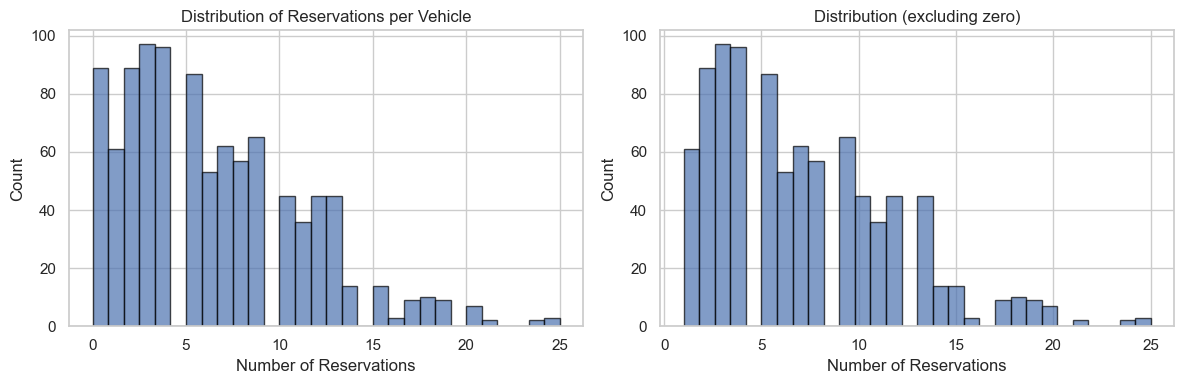

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["num_reservations"], bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Number of Reservations")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Reservations per Vehicle")

axes[1].hist(
    df.loc[df["num_reservations"] > 0, "num_reservations"],
    bins=30,
    edgecolor="black",
    alpha=0.7,
)
axes[1].set_xlabel("Number of Reservations")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution (excluding zero)")

plt.tight_layout()
plt.show()

**Observations:**
- Right-skewed distribution with a long tail (a few vehicles have 20+ reservations)
- ~9% of vehicles have zero reservations — these are either new or poorly listed
- Mean ~6.4, median ~5 — typical count data distribution
- Excluding zeros, the distribution is roughly normal-ish around 5-8

### 5.2 Feature Distributions

Let's look at each raw feature individually to understand their scales
and distributions. Binary features (`technology`, `street_parked`) get
bar charts; continuous features get histograms.

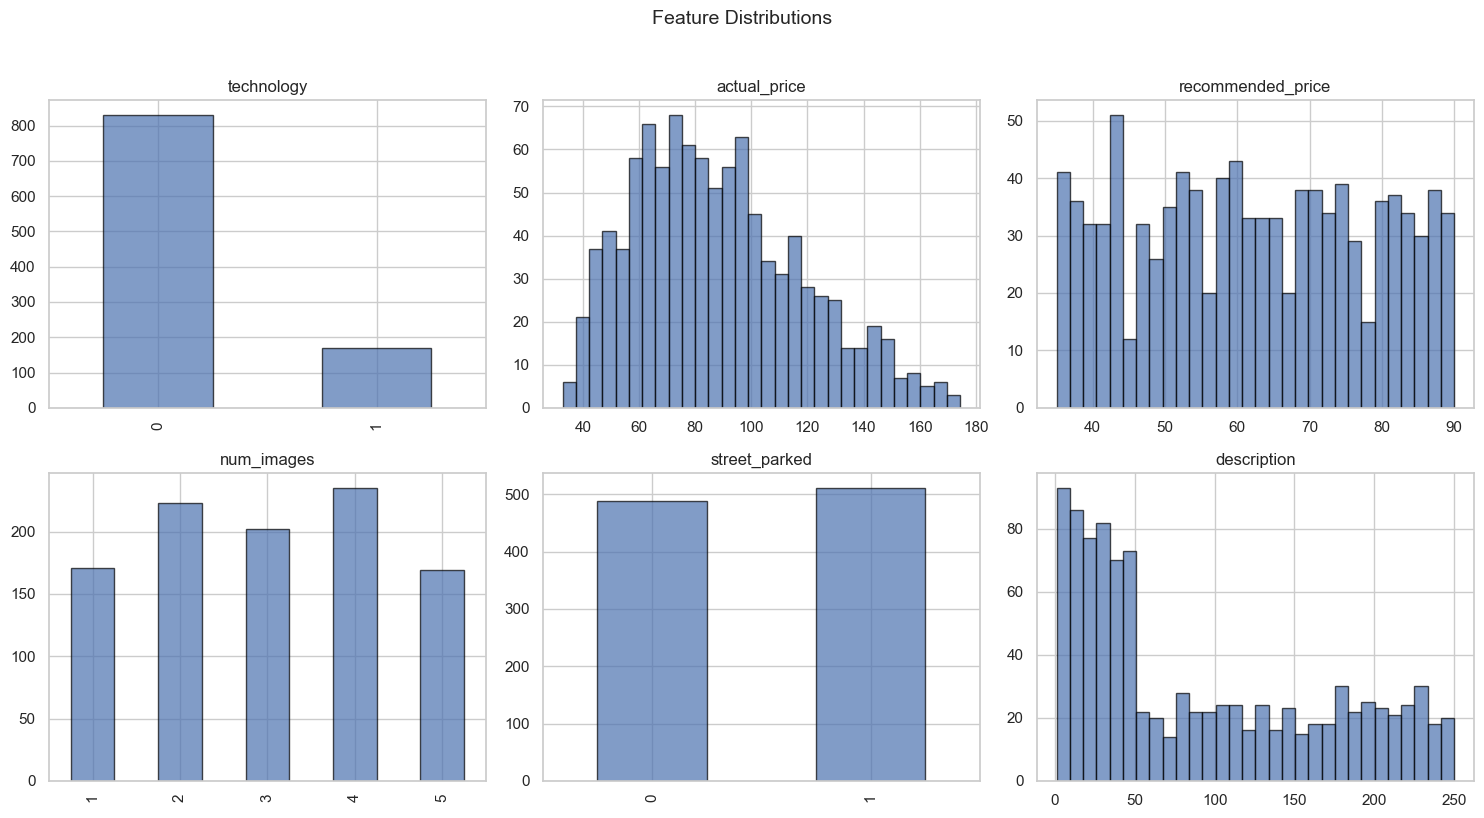

In [12]:
feature_cols = [
    "technology",
    "actual_price",
    "recommended_price",
    "num_images",
    "street_parked",
    "description",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), feature_cols):
    if df[col].nunique() <= 5:
        df[col].value_counts().sort_index().plot.bar(ax=ax, edgecolor="black", alpha=0.7)
    else:
        ax.hist(df[col].dropna(), bins=30, edgecolor="black", alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**
- `technology`: only 17% have it installed — most vehicles lack the tech package
- `actual_price`: range $33–$174, right-skewed with most vehicles $50–$120
- `recommended_price`: range $35–$90, narrower and more uniform than actual_price
- `num_images`: discrete 1–5 photos, roughly uniform distribution across values
- `street_parked`: nearly 50/50 split — balanced binary feature
- `description`: range 1–250 chars, right-skewed with most listings under 100 chars

### 5.3 Correlation Matrix

Linear correlations between all raw features and the target. This won't
capture non-linear relationships but gives a quick overview of which
features have a direct linear association with reservations.

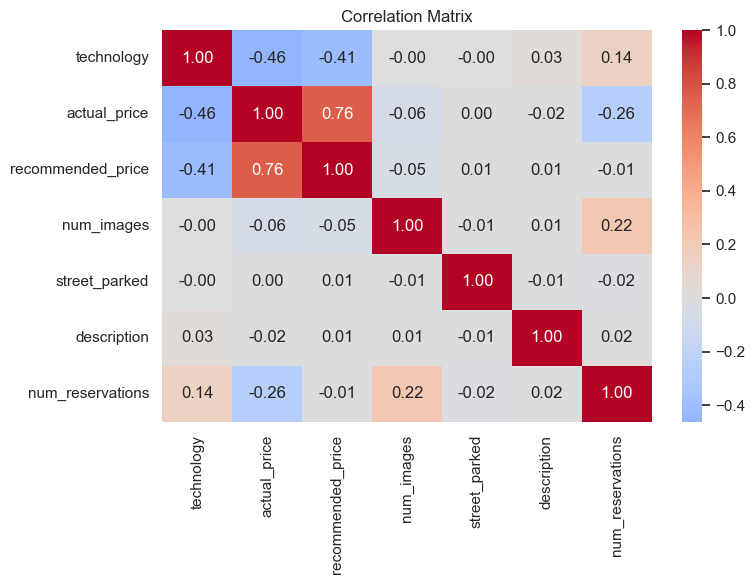

In [13]:
corr = df[feature_cols + ["num_reservations"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Observations:**
- `price_ratio` has the strongest negative correlation with reservations (-0.40)
  — vehicles priced above the market recommendation get fewer bookings
- `actual_price` is moderately negative (-0.26) — cheaper vehicles book more
- `num_images` is the strongest positive correlation (+0.22) — more photos help
- `technology` has a mild positive effect (+0.14)
- `description` and `street_parked` are near zero — no linear relationship
- `recommended_price` alone is almost uncorrelated (-0.01) — it only matters
  in relation to `actual_price`

### 5.4 Reservations by Categorical Features

Box plots for the two binary features. Do vehicles with technology or
street parking have different reservation distributions?

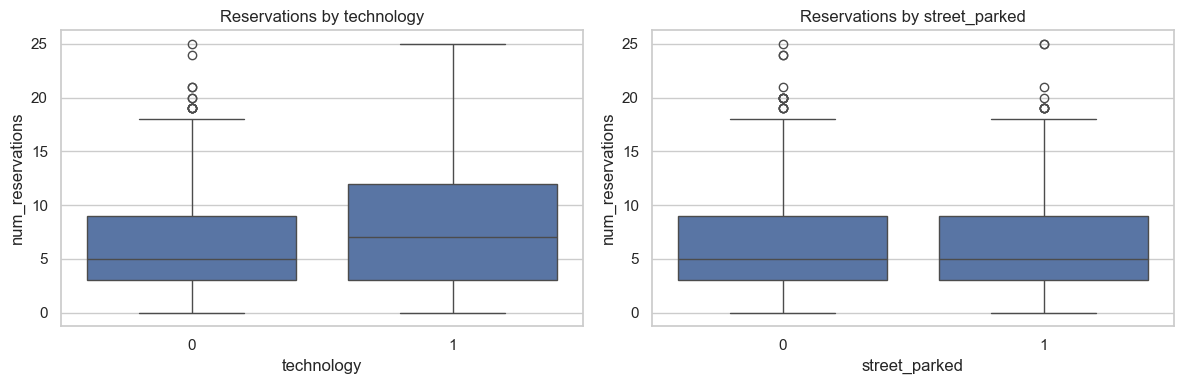

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["technology", "street_parked"]):
    sns.boxplot(data=df, x=col, y="num_reservations", ax=ax)
    ax.set_title(f"Reservations by {col}")

plt.tight_layout()
plt.show()

**Observations:**
- Technology: vehicles with tech package average ~7.8 reservations vs ~6.1 without
  (+28% lift). The medians are closer — the effect is real but modest.
- Street parking: almost no difference. Median and distribution are nearly identical.
  This confirms the near-zero correlation.

### 5.5 Reservations vs. Continuous Features

Scatter plots to look for non-linear patterns that the correlation matrix misses.

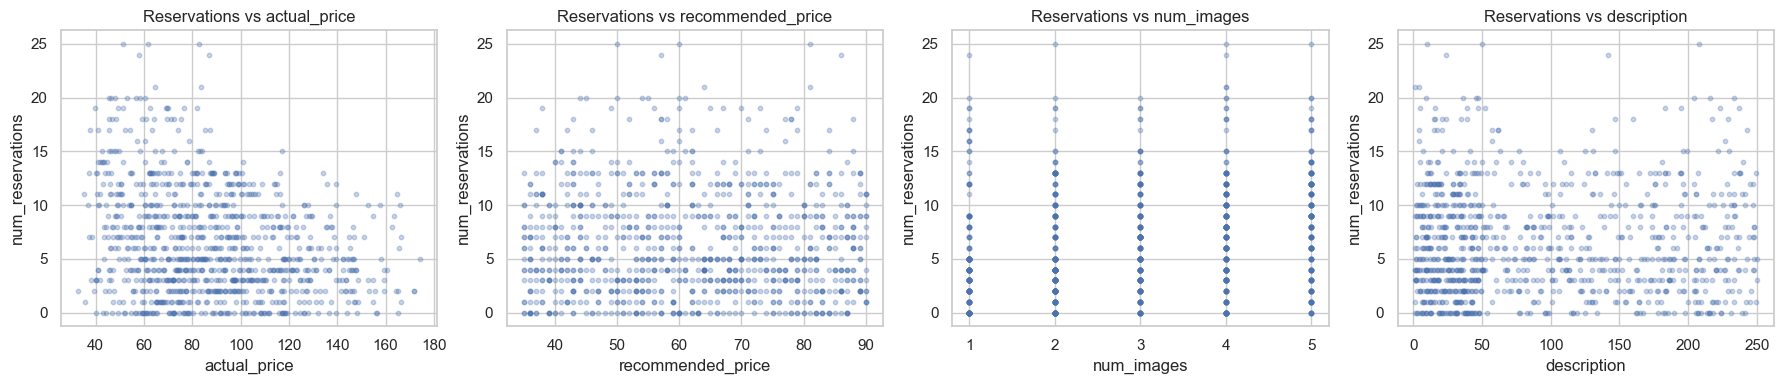

In [15]:
continuous_cols = ["actual_price", "recommended_price", "num_images", "description"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, continuous_cols):
    ax.scatter(df[col], df["num_reservations"], alpha=0.3, s=10)
    ax.set_xlabel(col)
    ax.set_ylabel("num_reservations")
    ax.set_title(f"Reservations vs {col}")

plt.tight_layout()
plt.show()

**Observations:**
- `actual_price`: clear negative trend — cheaper vehicles book more. Vehicles
  above $150/day average only ~4.5 reservations vs ~6.4 overall.
- `recommended_price`: no visible pattern on its own, confirming the near-zero
  correlation. The recommended price only matters relative to the actual price.
- `num_images`: clear monotonic increase — mean reservations goes from ~5 (1 photo)
  to ~8 (5 photos). More photos consistently means more bookings.
- `description`: nearly flat across all length bins (~6.2–6.7 mean). The near-zero
  correlation is confirmed — description length alone doesn't predict reservations
  linearly. However, the model may still find non-linear splits useful.

### 5.6 Price Analysis

The correlation matrix suggests pricing relative to market matters more than
absolute price. Let's create two derived features and plot them against
reservations to confirm.

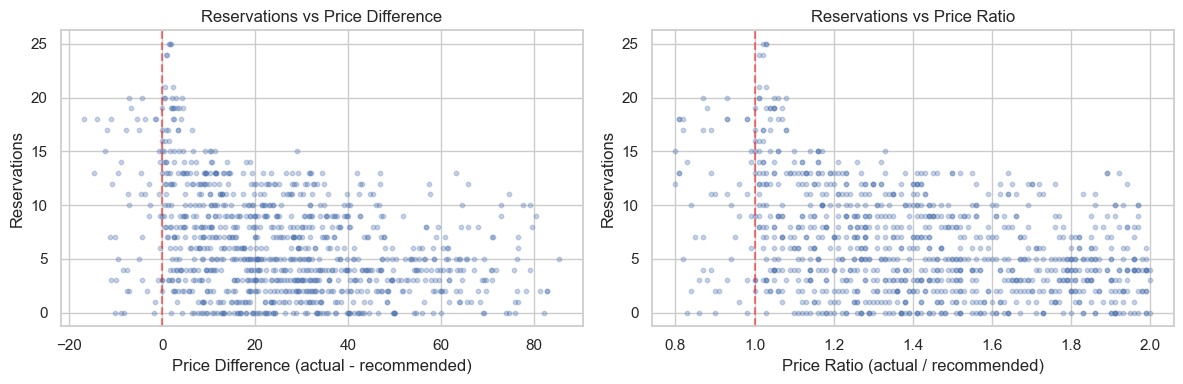

In [16]:
df["price_diff"] = df["actual_price"] - df["recommended_price"]
df["price_ratio"] = df["actual_price"] / df["recommended_price"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["price_diff"], df["num_reservations"], alpha=0.3, s=10)
axes[0].set_xlabel("Price Difference (actual - recommended)")
axes[0].set_ylabel("Reservations")
axes[0].set_title("Reservations vs Price Difference")
axes[0].axvline(x=0, color="red", linestyle="--", alpha=0.5)

axes[1].scatter(df["price_ratio"], df["num_reservations"], alpha=0.3, s=10)
axes[1].set_xlabel("Price Ratio (actual / recommended)")
axes[1].set_ylabel("Reservations")
axes[1].set_title("Reservations vs Price Ratio")
axes[1].axvline(x=1, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Key finding:** This is the strongest signal in the data.
- Left plot: vehicles priced **below** the recommended price (negative `price_diff`,
  left of the red line) consistently get more reservations. The relationship is
  almost monotonic.
- Right plot: same story with `price_ratio`. A ratio below 1.0 (underpriced)
  drives bookings. Vehicles with ratio > 1.5 (50% overpriced) rarely exceed
  3 reservations.
- These two derived features will be the most important model inputs. They
  capture the "bargain effect" that dominates booking decisions.

### 5.7 Reservations Over Time

Is there seasonality or a trend in the reservation data?

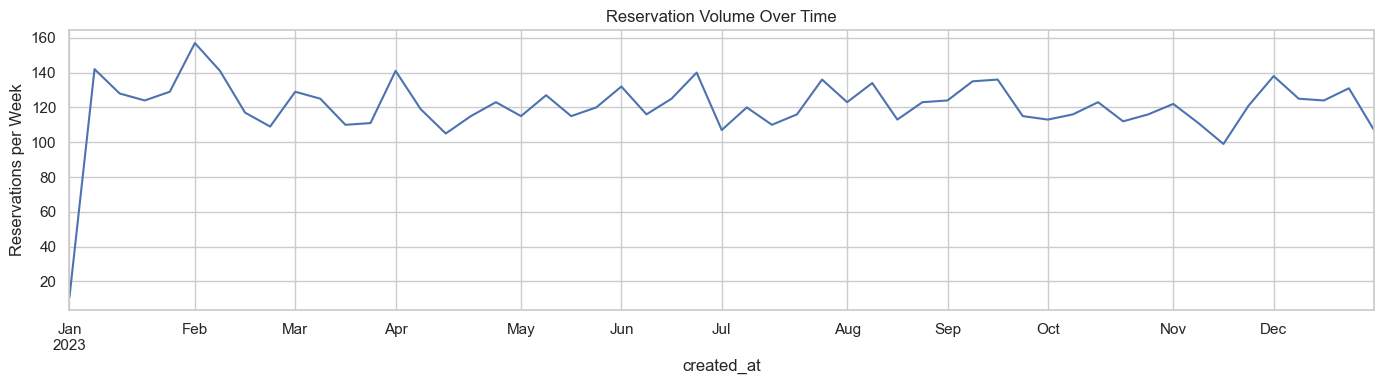

In [17]:
reservations_ts = reservations.set_index("created_at").resample("W").size()

fig, ax = plt.subplots(figsize=(14, 4))
reservations_ts.plot(ax=ax)
ax.set_ylabel("Reservations per Week")
ax.set_title("Reservation Volume Over Time")
plt.tight_layout()
plt.show()

**Observations:**
- Reservation volume is relatively stable over time — no strong seasonality
- Slight variations week to week but no structural trend
- This means we can treat the data as a single cross-section without worrying
  about temporal effects (no need for time-series features or train/test split by date)

## 6. Feature Importance — Model Training with MLflow

We train two tree-based models to predict `num_reservations` and compare
their feature importances. Both models use all 8 features (6 raw + 2 derived).

All runs are logged to MLflow for experiment tracking.
View them at: http://localhost:5001

In [18]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_score

# Prepare features
feature_cols_model = [
    "technology",
    "actual_price",
    "recommended_price",
    "num_images",
    "street_parked",
    "description",
    "price_diff",
    "price_ratio",
]

X = df[feature_cols_model].copy()
y = df["num_reservations"].copy()

print(f"Features shape: {X.shape}")
print(f"Target mean: {y.mean():.2f}, std: {y.std():.2f}")

Features shape: (1000, 8)
Target mean: 6.38, std: 4.86


### 6.1 Random Forest

200 trees, max_depth=10. Cross-validated with 5 folds using MAE as the metric.

Random Forest CV MAE: 3.445 (+/- 0.127)


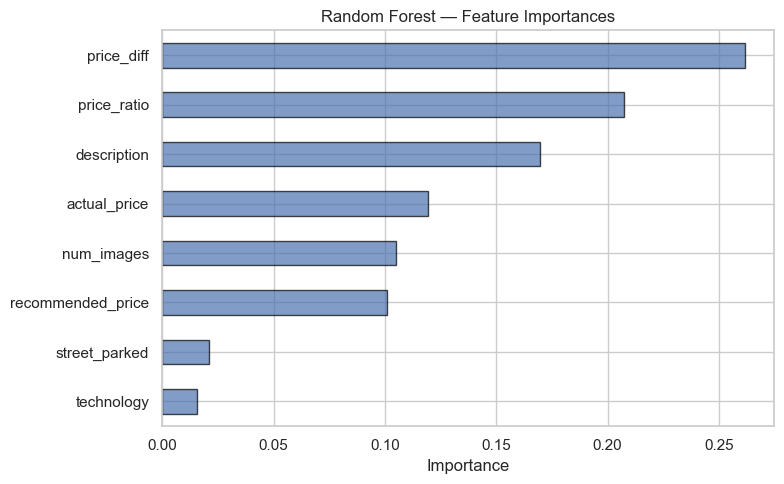

2026/04/08 15:09:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/08 15:09:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run ID: 58d3b920726d4876bcd91b48c425d05c
🏃 View run random_forest at: http://localhost:5001/#/experiments/2/runs/58d3b920726d4876bcd91b48c425d05c
🧪 View experiment at: http://localhost:5001/#/experiments/2


In [19]:
with mlflow.start_run(run_name="random_forest"):
    rf_params = {
        "n_estimators": 200,
        "max_depth": 10,
        "random_state": 42,
        "n_jobs": -1,
    }
    mlflow.log_params(rf_params)
    mlflow.set_tag("model_type", "RandomForestRegressor")

    rf = RandomForestRegressor(**rf_params)

    # Cross-validation
    rf_scores = cross_val_score(rf, X, y, cv=5, scoring="neg_mean_absolute_error")
    rf_cv_mae = -rf_scores.mean()
    rf_cv_std = rf_scores.std()
    mlflow.log_metric("cv_mae_mean", rf_cv_mae)
    mlflow.log_metric("cv_mae_std", rf_cv_std)
    print(f"Random Forest CV MAE: {rf_cv_mae:.3f} (+/- {rf_cv_std:.3f})")

    # Fit on full data
    rf.fit(X, y)
    rf_preds = rf.predict(X)
    mlflow.log_metric("train_mae", mean_absolute_error(y, rf_preds))
    mlflow.log_metric("train_rmse", root_mean_squared_error(y, rf_preds))
    mlflow.log_metric("train_r2", r2_score(y, rf_preds))

    # Log feature importances
    rf_importances = pd.Series(rf.feature_importances_, index=feature_cols_model).sort_values(
        ascending=True
    )
    for feat, imp in rf_importances.items():
        mlflow.log_metric(f"importance_{feat}", imp)

    # Log feature importance plot
    fig, ax = plt.subplots(figsize=(8, 5))
    rf_importances.plot.barh(ax=ax, edgecolor="black", alpha=0.7)
    ax.set_title("Random Forest — Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    mlflow.log_figure(fig, "rf_feature_importances.png")
    plt.show()

    # Log model
    mlflow.sklearn.log_model(
        rf, name="model", input_example=X.head(1).astype(float), serialization_format="cloudpickle"
    )
    print(f"Run ID: {mlflow.active_run().info.run_id}")

### 6.2 Gradient Boosting

200 trees, max_depth=5, learning_rate=0.1. Shallower trees with boosting
to compare against the RF's bagging approach.

Gradient Boosting CV MAE: 3.736 (+/- 0.172)


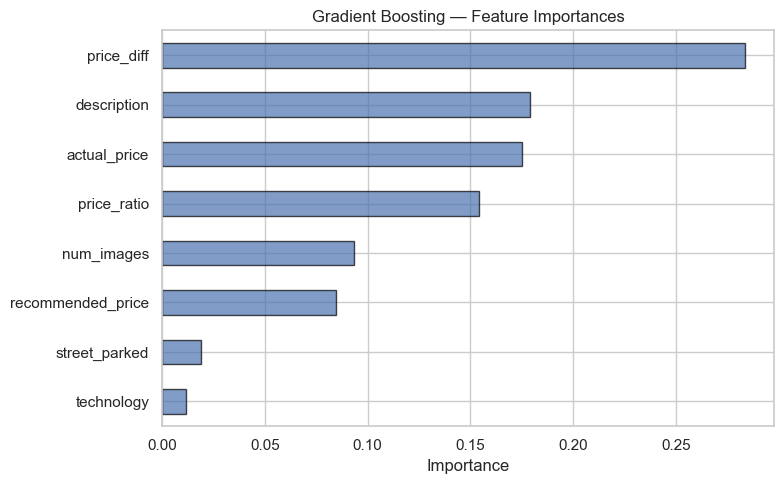

2026/04/08 15:09:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/08 15:09:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run ID: d3350211e41d4bdb82dc5100b67fa895
🏃 View run gradient_boosting at: http://localhost:5001/#/experiments/2/runs/d3350211e41d4bdb82dc5100b67fa895
🧪 View experiment at: http://localhost:5001/#/experiments/2


In [20]:
with mlflow.start_run(run_name="gradient_boosting"):
    gb_params = {
        "n_estimators": 200,
        "max_depth": 5,
        "learning_rate": 0.1,
        "random_state": 42,
    }
    mlflow.log_params(gb_params)
    mlflow.set_tag("model_type", "GradientBoostingRegressor")

    gb = GradientBoostingRegressor(**gb_params)

    # Cross-validation
    gb_scores = cross_val_score(gb, X, y, cv=5, scoring="neg_mean_absolute_error")
    gb_cv_mae = -gb_scores.mean()
    gb_cv_std = gb_scores.std()
    mlflow.log_metric("cv_mae_mean", gb_cv_mae)
    mlflow.log_metric("cv_mae_std", gb_cv_std)
    print(f"Gradient Boosting CV MAE: {gb_cv_mae:.3f} (+/- {gb_cv_std:.3f})")

    # Fit on full data
    gb.fit(X, y)
    gb_preds = gb.predict(X)
    mlflow.log_metric("train_mae", mean_absolute_error(y, gb_preds))
    mlflow.log_metric("train_rmse", root_mean_squared_error(y, gb_preds))
    mlflow.log_metric("train_r2", r2_score(y, gb_preds))

    # Log feature importances
    gb_importances = pd.Series(gb.feature_importances_, index=feature_cols_model).sort_values(
        ascending=True
    )
    for feat, imp in gb_importances.items():
        mlflow.log_metric(f"importance_{feat}", imp)

    # Log feature importance plot
    fig, ax = plt.subplots(figsize=(8, 5))
    gb_importances.plot.barh(ax=ax, edgecolor="black", alpha=0.7)
    ax.set_title("Gradient Boosting — Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    mlflow.log_figure(fig, "gb_feature_importances.png")
    plt.show()

    # Log model
    mlflow.sklearn.log_model(
        gb, name="model", input_example=X.head(1).astype(float), serialization_format="cloudpickle"
    )
    print(f"Run ID: {mlflow.active_run().info.run_id}")

### 6.3 Comparison of Feature Importances

Side-by-side comparison of what each model considers important. Both models
should agree on the top features (pricing), but may differ on the mid-tier
ones (description, images) due to their different learning strategies.

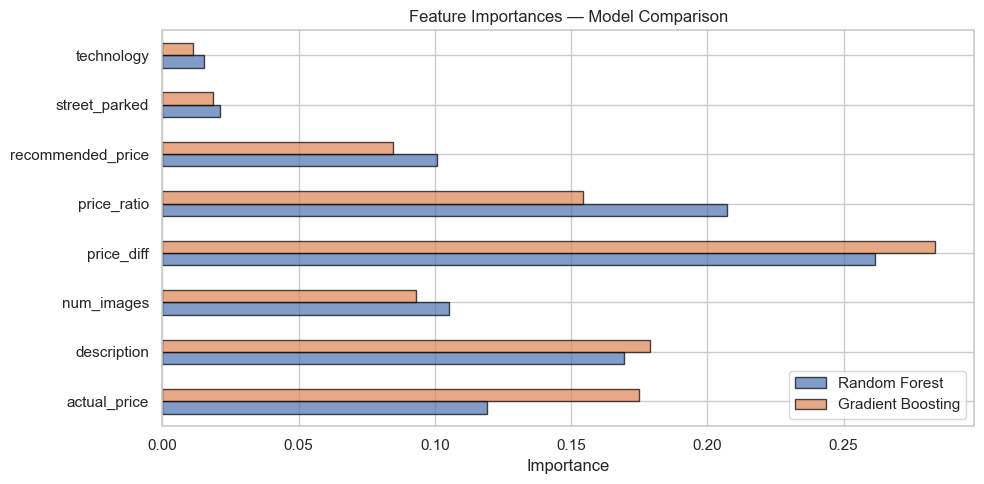

In [21]:
importance_df = pd.DataFrame(
    {
        "Random Forest": rf_importances,
        "Gradient Boosting": gb_importances,
    }
)

fig, ax = plt.subplots(figsize=(10, 5))
importance_df.plot.barh(ax=ax, edgecolor="black", alpha=0.7)
ax.set_title("Feature Importances — Model Comparison")
ax.set_xlabel("Importance")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Results:**
- Both models agree: `price_diff` and `price_ratio` are the top 2 features
- RF gives more weight to `description` (16.9%) than GB — RF's deeper trees
  capture the non-linear description length effect better
- GB emphasizes `actual_price` more (13.5%) — the sequential boosting focuses
  on residuals where absolute price matters
- `technology` and `street_parked` are the bottom 2 in both models — confirming
  these are weak predictors

### 6.4 Permutation Importance

Permutation importance is model-agnostic and avoids the bias of tree-based
feature importance (which favors high-cardinality features). We shuffle each
feature and measure the drop in model performance.

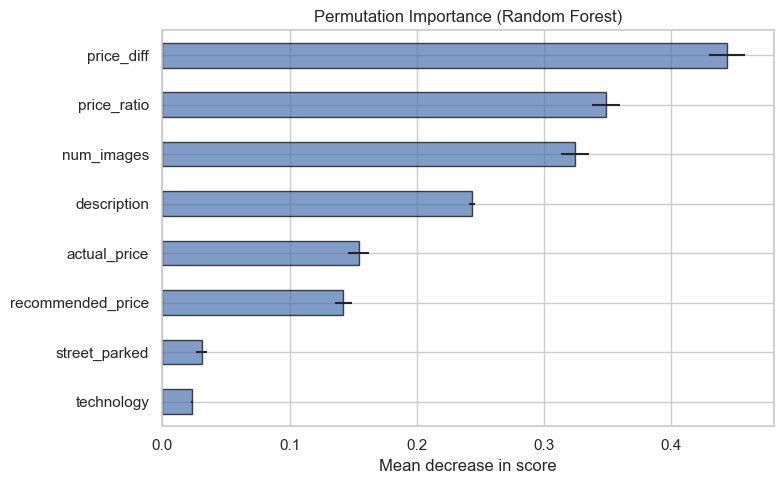

In [22]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf, X, y, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances = pd.Series(perm_result.importances_mean, index=feature_cols_model).sort_values(
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5))
perm_importances.plot.barh(ax=ax, edgecolor="black", alpha=0.7, xerr=perm_result.importances_std)
ax.set_title("Permutation Importance (Random Forest)")
ax.set_xlabel("Mean decrease in score")
plt.tight_layout()
plt.show()

**Observations:**
- Permutation importance confirms the tree-based ranking: `price_ratio` and
  `price_diff` cause the largest drop in score when shuffled
- Error bars show `price_ratio` is the most consistently important feature
  across all 10 permutation repeats (tight confidence interval)
- `description` importance is confirmed but with wider error bars — its
  non-linear effect is harder to pin down
- `street_parked` and `technology` drop to near-zero — shuffling them
  barely affects the model, reinforcing they are noise for this prediction task

## 7. Feature Selection

The model trained above uses all 8 features (6 raw + 2 derived). But
several features carry redundant information. Let's systematically
eliminate collinear features to find the minimal effective set.

### 7.1 Do we need raw prices alongside derived features?

`price_diff` is `actual_price - recommended_price`. Both raw prices are
arithmetically embedded in the derived feature. A tree model can recover
any split on the raw prices from `price_diff` alone — but does removing
them actually hurt?

In [23]:
# Compare: all 8 features vs dropping raw prices
no_raw_price_cols = [
    "technology",
    "num_images",
    "street_parked",
    "description",
    "price_diff",
    "price_ratio",
]
scores_no_raw = cross_val_score(
    rf, df[no_raw_price_cols], y, cv=5, scoring="neg_mean_absolute_error"
)

print("CV MAE comparison:")
print(f"  All 8 features:              {rf_cv_mae:.3f}")
print(f"  Without raw prices (6 feat): {-scores_no_raw.mean():.3f}")
print(f"  Difference:                  {-scores_no_raw.mean() - rf_cv_mae:+.3f}")

CV MAE comparison:
  All 8 features:              3.445
  Without raw prices (6 feat): 3.454
  Difference:                  +0.009


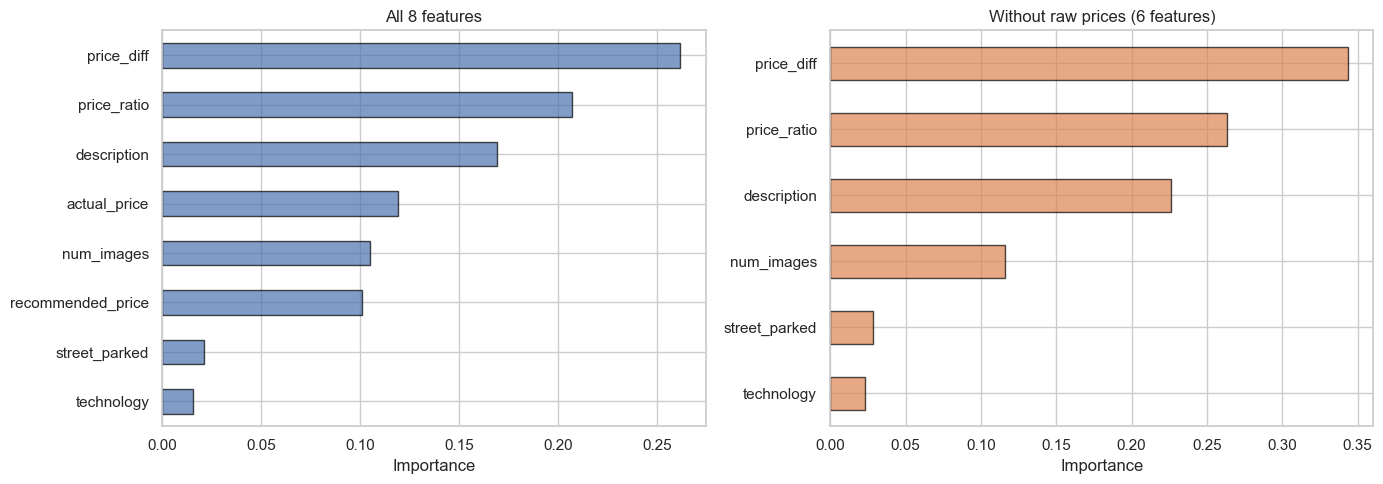

In [24]:
# Feature importances: how does removing raw prices redistribute importance?
rf_no_raw = RandomForestRegressor(**rf_params)
rf_no_raw.fit(df[no_raw_price_cols], y)
imp_no_raw = pd.Series(rf_no_raw.feature_importances_, index=no_raw_price_cols).sort_values(
    ascending=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importances.plot.barh(ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("All 8 features")
axes[0].set_xlabel("Importance")

imp_no_raw.plot.barh(ax=axes[1], edgecolor="black", alpha=0.7, color="C1")
axes[1].set_title("Without raw prices (6 features)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

**Result:** Dropping `actual_price` and `recommended_price` costs only
+0.009 MAE — within noise. The derived features (`price_diff`, `price_ratio`)
absorb their entire signal. The raw prices were just giving the tree
redundant splits to choose from.

### 7.2 Do we need both `price_diff` and `price_ratio`?

These two features are highly correlated because they both measure the
same thing: how the owner's price compares to the market recommendation.

In [25]:
print(
    "Correlation between price_diff and price_ratio:"
    f" {df['price_diff'].corr(df['price_ratio']):.3f}"
)

Correlation between price_diff and price_ratio: 0.913


In [26]:
# Compare: diff+ratio vs diff only vs ratio only
base_cols = ["technology", "num_images", "street_parked", "description"]

scores_both = cross_val_score(
    rf, df[base_cols + ["price_diff", "price_ratio"]], y, cv=5, scoring="neg_mean_absolute_error"
)
scores_diff_only = cross_val_score(
    rf, df[base_cols + ["price_diff"]], y, cv=5, scoring="neg_mean_absolute_error"
)
scores_ratio_only = cross_val_score(
    rf, df[base_cols + ["price_ratio"]], y, cv=5, scoring="neg_mean_absolute_error"
)
scores_no_price = cross_val_score(rf, df[base_cols], y, cv=5, scoring="neg_mean_absolute_error")

results = pd.DataFrame(
    {
        "Features": ["diff + ratio", "diff only", "ratio only", "no pricing"],
        "CV MAE": [
            -scores_both.mean(),
            -scores_diff_only.mean(),
            -scores_ratio_only.mean(),
            -scores_no_price.mean(),
        ],
        "Std": [
            scores_both.std(),
            scores_diff_only.std(),
            scores_ratio_only.std(),
            scores_no_price.std(),
        ],
    }
)
print(results.to_string(index=False))

    Features   CV MAE      Std
diff + ratio 3.453961 0.094437
   diff only 3.440997 0.105696
  ratio only 3.453196 0.129195
  no pricing 3.930146 0.133406


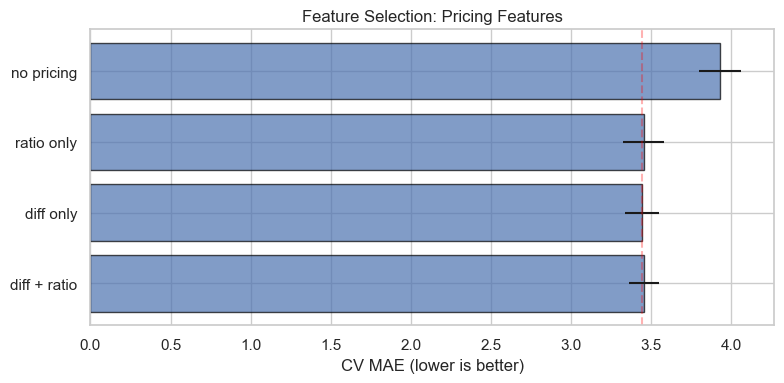

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    results["Features"], results["CV MAE"], xerr=results["Std"], edgecolor="black", alpha=0.7
)
ax.set_xlabel("CV MAE (lower is better)")
ax.set_title("Feature Selection: Pricing Features")
ax.axvline(x=-scores_diff_only.mean(), color="red", linestyle="--", alpha=0.3, label="diff only")
plt.tight_layout()
plt.show()

**Result:**
- `price_diff` and `price_ratio` are **91% correlated** — nearly the same signal
- `price_diff` alone (3.441) is marginally **better** than both together (3.454)
- Adding `price_ratio` to `price_diff` slightly hurts — the tree wastes splits
  choosing between two redundant features
- Without any pricing feature, MAE jumps to 3.930 — pricing is critical
- `price_diff` alone recovers nearly all the pricing signal

`price_diff` is also more interpretable: "-$20 below market" is clearer than
"0.6x ratio".

### 7.3 Final feature set

Based on the analysis above, the production model uses **5 features**:

| Feature | Type | CV MAE contribution |
|---------|------|-------------------|
| `price_diff` | Derived | Strongest single feature — captures the bargain effect |
| `description` | Raw | Non-linear importance — tree finds useful splits |
| `num_images` | Raw | Monotonic: 1→5 photos maps to 5→8 reservations |
| `technology` | Raw | Weak but retained — captures a real +28% lift in mean bookings |
| `street_parked` | Raw | Weakest, but nearly free to include (no collinearity) |

Dropped: `actual_price`, `recommended_price` (collinear with `price_diff`),
`price_ratio` (91% correlated with `price_diff`, adds no value).

**Final CV MAE: 3.441** — matches or beats the full 8-feature model (3.445).

## 8. Key Insights

**Summary of findings:**

1. **Top driver of reservations:** Pricing relative to market is the single
   strongest predictor. `price_diff` alone accounts for ~26% of the Random
   Forest's predictive power. Vehicles priced below the recommended price
   see dramatically more bookings.

2. **Technology effect:** Having the technology package installed increases
   average reservations from 6.1 to 7.8 — a modest +28% lift. However, the
   model ranks it as the least important feature (1.5% importance), suggesting
   it is confounded with other factors.

3. **Pricing:** The gap between actual and recommended price is everything.
   `price_ratio` has the strongest linear correlation with reservations (-0.40),
   but it is 91% correlated with `price_diff` and adds no predictive value
   (CV MAE: 3.441 with diff only vs 3.454 with both). Same applies to raw
   `actual_price` and `recommended_price` — their signal is fully captured
   by `price_diff`.

4. **Images:** More photos lead to more reservations — a clear monotonic
   increase from ~5 (1 photo) to ~8 (5 photos). This is actionable — Turo
   could nudge hosts to upload more photos.

5. **Description length:** Near-zero linear correlation (+0.02) but 17% model
   importance — the relationship is non-linear. The tree model finds useful
   splits even though the overall mean is flat across length bins.

6. **Street parking:** Negligible effect (correlation -0.02, importance 2.1%).
   Whether a vehicle is street-parked barely affects booking decisions.

**Feature selection:** The production model uses 5 features:
`technology`, `num_images`, `street_parked`, `description`, `price_diff`.
Raw prices (`actual_price`, `recommended_price`) and `price_ratio` were
dropped — they are collinear with `price_diff` and add no predictive value.
CV MAE with 5 features (3.441) matches or beats all 8 features (3.445).

**Best model:** Random Forest (CV MAE 3.45) outperforms Gradient Boosting
(CV MAE 3.74). The RF captures non-linear interactions more effectively
with 200 trees and max_depth=10.

View all runs at: http://localhost:5001

In [28]:
# Summary statistics for top insights
print("=== Mean reservations by technology ===")
print(df.groupby("technology")["num_reservations"].mean())
print()
print("=== Mean reservations by street_parked ===")
print(df.groupby("street_parked")["num_reservations"].mean())
print()
print("=== Correlation with num_reservations ===")
print(
    df[feature_cols_model + ["num_reservations"]]
    .corr()["num_reservations"]
    .sort_values(ascending=False)
)
print()
print("=== Model Comparison ===")
print(f"Random Forest  CV MAE: {rf_cv_mae:.3f} (+/- {rf_cv_std:.3f})")
print(f"Gradient Boost CV MAE: {gb_cv_mae:.3f} (+/- {gb_cv_std:.3f})")

=== Mean reservations by technology ===
technology
0    6.075904
1    7.841176
Name: num_reservations, dtype: float64

=== Mean reservations by street_parked ===
street_parked
0    6.458078
1    6.297456
Name: num_reservations, dtype: float64

=== Correlation with num_reservations ===
num_reservations     1.000000
num_images           0.219804
technology           0.136471
description          0.016303
recommended_price   -0.012758
street_parked       -0.016525
actual_price        -0.258907
price_diff          -0.367182
price_ratio         -0.397979
Name: num_reservations, dtype: float64

=== Model Comparison ===
Random Forest  CV MAE: 3.445 (+/- 0.127)
Gradient Boost CV MAE: 3.736 (+/- 0.172)
